In [177]:
import matplotlib.pyplot as plt
plt.rcParams['font.serif'] = ['Times'] + plt.rcParams['font.serif']
plt.rcParams['text.usetex'] = False
plt.rcParams["ps.usedistiller"] = 'xpdf'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.weight'] = 'normal'
plt.rcParams["mathtext.fontset"] = 'cm'

In [178]:
import numpy as np
import pynumdiff
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.colors as colors
import pandas
import random
import figurefirst as fifi

from matplotlib import patches
from matplotlib.collections import PatchCollection

# the following come from this repository: https://github.com/vanbreugel-lab/braid_tools
from braid_analysis import braid_analysis_plots
from braid_analysis import flymath

In [179]:
# custom colormap

import matplotlib.colors as mcolors
import colorsys
import matplotlib

# Get the YlGnBu colormap
cmap = matplotlib.colormaps['YlGnBu']

# Function to adjust luminosity
def adjust_luminosity(rgb, factor=1.0):
    # Convert RGB to HLS
    hls = colorsys.rgb_to_hls(*rgb)
    # Keep hue constant, adjust luminosity (lightness)
    return colorsys.hls_to_rgb(hls[0], factor, hls[2])

# Create the custom colormap with constant luminosity
def create_constant_luminosity_cmap(cmap, n=256, luminosity_factor=0.5):
    colors = cmap(np.linspace(0, 1, n))[:, :3]  # Get RGB values, exclude alpha channel
    adjusted_colors = [adjust_luminosity(color, luminosity_factor) for color in colors]
    return mcolors.ListedColormap(adjusted_colors)

# Create the custom colormap
YlGnBu_const_lum = create_constant_luminosity_cmap(cmap, luminosity_factor=0.5)


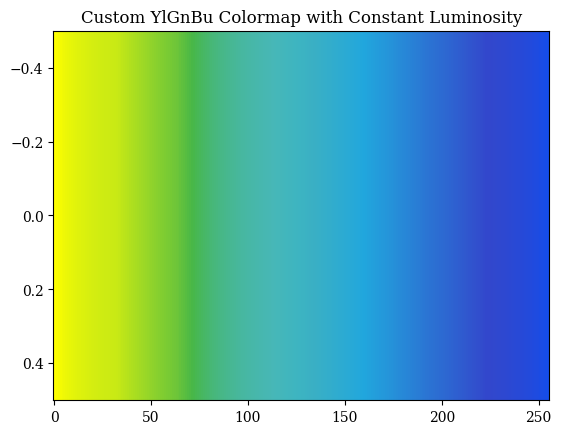

In [180]:
plt.imshow(np.linspace(0, 1, 256)[np.newaxis, :], aspect='auto', cmap=YlGnBu_const_lum)
plt.title("Custom YlGnBu Colormap with Constant Luminosity")
plt.show()

In [181]:
random.seed(1)

In [182]:
CLOCK_AMPLITUDE = 60
LAMBDA = 18 # 25
UPWIND_BIAS = 0.08
FIGURE_TEMPLATE = 'unifying_algo_newdraft_with_summary.svg'
XY_PLOT_RANGE = 0.65
VEL_NOISE_STD = 0.1

In [183]:
def wrap(angle):
    return np.arctan2(np.sin(angle), np.cos(angle))

def vector_strength(wind_direction, wind_speed):
    # vector strength is just the sum of the vectors..

    if 0:
        wind_vec = np.vstack( (wind_speed*np.cos(wind_direction),
                                  wind_speed*np.sin(wind_direction)))
    else:
        wind_vec = np.vstack( (np.cos(wind_direction),
                                  np.sin(wind_direction)))
    
    return np.linalg.norm( np.sum(wind_vec, axis=1) / len(wind_direction) )


In [184]:
def median_angle(angle):
    return np.arctan2(np.median(np.sin(angle)), np.median(np.cos(angle)))

def unwrap_angle(z, correction_window_for_2pi=5, n_range=2, plot=False):
    # automatically scales n_range to most recent value, and maybe faster
    smooth_zs = np.array(z[0:2])
    for i in range(2, len(z)):
        first_ix = np.max([0, i-correction_window_for_2pi])
        last_ix = i
        
        nbase = np.round( (smooth_zs[-1] - z[i])/(2*np.pi) )
        
        candidates = []
        for n in range(-1*n_range, n_range):
            candidates.append(n*2*np.pi+nbase*2*np.pi+z[i])
        error = np.abs(candidates - np.mean(smooth_zs[first_ix:last_ix])) 
        smooth_zs = np.hstack(( smooth_zs, [candidates[np.argmin(error)]] ))
    if plot:
        plt.plot(smooth_zs, '.', color='black', markersize=1)
    return smooth_zs

def diff_angle(angles, dt, params, 
               derivative_method='smooth_finite_difference.butterdiff', 
               correction_window_for_2pi=5):
    '''
    Take a filtered derivative of an angle
    '''
    family, method = derivative_method.split('.')
    unwrapped_angle = unwrap_angle(angles, correction_window_for_2pi=correction_window_for_2pi, n_range=5)
    angles_smooth, angles_dot = pynumdiff.__dict__[family].__dict__[method](unwrapped_angle, dt, params, {})

    return wrap(angles_smooth), angles_dot

In [185]:
def get_wind_adjusted_goal_array(goal_A, wind_direction, wind_speed, weight=50):
    
    vec_str_wind = vector_strength(wind_direction, wind_speed)
    goal_B_vec_list = []
    goal_B_list = []
    goal_C_list = []
    
    # smooth wind direction
    wind_direction, _ = diff_angle(wind_direction, dt, [2, 0.03], 
                                           derivative_method='smooth_finite_difference.butterdiff', 
                                           correction_window_for_2pi=5)
    lambdas = []
    for i in range(len(goal_A)):
        
        # shift unit wind vector by 90 degrees, create unit vector for initial goal vector
        try:
            wd = wind_direction[i]
        except:
            wd = wind_direction
        unit_wind_vector = np.array([np.cos(wd), np.sin(wd)])
        wd_shifted = wrap(wd + np.pi/2)
        unit_wind_vector_shifted = np.array([np.cos(wd_shifted), np.sin(wd_shifted)])
        wind_vector_shifted = wind_speed[i]*np.array([np.cos(wd_shifted), np.sin(wd_shifted)])
        goal_A_vector = np.array([np.cos(goal_A[i]), np.sin(goal_A[i])])
        
        # dot product of the two vectors
        goal_B_vec = np.dot(unit_wind_vector_shifted, goal_A_vector)*unit_wind_vector_shifted
        # add a little bit of upwind bias
        goal_B_vec = ((1-UPWIND_BIAS)*goal_B_vec - UPWIND_BIAS*unit_wind_vector)
        goal_B_vec_list.append(goal_B_vec)
        
        goal_B = np.arctan2(goal_B_vec[1], goal_B_vec[0])
        goal_B_list.append(goal_B)
        
        # weighted sum of initial goal vector and dot product
        #print(weight*vec_str_wind)
        goal_C_vec = goal_A_vector/np.linalg.norm(goal_A_vector) + weight*vec_str_wind**0.5*wind_speed[i]*(goal_B_vec) #/np.linalg.norm(goal_B_vec)

        lambdas.append(np.abs(weight)*np.abs(vec_str_wind)**0.5*np.abs(wind_speed[i]))
        
        goal_C_vec = goal_C_vec / np.linalg.norm(goal_C_vec)

        # extract new goal direction
        goal_C = np.arctan2(goal_C_vec[1], goal_C_vec[0])
        goal_C_list.append(goal_C)

    print('mean lambda: ' + str(np.mean(lambdas)))
    
    return np.array(goal_B_vec_list), np.array(goal_B_list), np.array(goal_C_list)

In [186]:
def get_wind_mag_dir(wind_type, dt, t0_ix=0, N_points=100000000):

    t = np.arange(0, dt*N_points, dt)

    if wind_type == 'steady' or wind_type == 'unsteady':
        wind = pandas.read_hdf('wind_data/'+wind_type+'_timeseries.hdf')
        df_time = wind.Time
        df_time_interp = np.arange(df_time.values[0], df_time.values[-1], dt)
    
        xvel_interp = np.interp(df_time_interp, df_time, wind.xvel.values)
        xvel_interp += np.random.normal(0, 0.01, len(df_time_interp))
        
        yvel_interp = np.interp(df_time_interp, df_time, wind.yvel.values)
        yvel_interp += np.random.normal(0, 0.01, len(df_time_interp))
        
        wind_mag = np.sqrt(xvel_interp**2 + yvel_interp**2)
        wind_dir = np.arctan2(yvel_interp, xvel_interp)
    
        wind_dir += np.pi
        wind_dir = wrap(wind_dir)
        
        last_point = t0_ix + N_points
        if last_point > len(wind_mag):
            raise ValueError('use a smaller t0_ix')
            
        wind_mag = wind_mag[t0_ix:last_point]
        wind_dir = wind_dir[t0_ix:last_point]

    if wind_type == 'laminar':
        wind_mag = 0.4*np.ones_like(t) + np.random.normal(0, 0.05, len(t))
        wind_dir = np.pi*np.ones_like(t) + np.random.normal(0, 0.05, len(t))

    if wind_type == 'stillair':
        wind_mag = 0.0001*np.ones_like(t) + np.random.normal(0, 0.005, len(t))
        wind_dir = np.pi*np.ones_like(t) + np.random.normal(0, 0.5, len(t))

    if wind_type == 'lowwind':
        wind_mag = 0.03*np.ones_like(t) + np.random.normal(0, 0.05, len(t))
        wind_dir = np.pi*np.ones_like(t) + np.random.normal(0, 0.1, len(t))
    
    return wind_mag, wind_dir

In [187]:
def get_goal_A_ground_speed_weight(initial_goal_A=90):
    clock_period = 0.3 # sec
    clock_period_std = 0.05
    clock_amplitude = CLOCK_AMPLITUDE #60 # deg
    clock_amplitude_std = 5 # deg
    clock_sign = np.sign(np.random.random()-0.5)
    
    ground_speed = 0.3*np.ones_like(t)
    weight = LAMBDA
    
    clock_steps = int(np.random.normal(clock_period, clock_period_std) / dt)
    goal_A = [initial_goal_A]*clock_steps
    while len(goal_A) < len(t):
        clock_steps = int(np.random.normal(clock_period, clock_period_std) / dt)
        goal_A.extend( [goal_A[-1] + clock_sign*np.random.normal(clock_amplitude, clock_amplitude_std)]*clock_steps )
        
    goal_A = goal_A[0:len(t)]
    goal_A = np.array(goal_A)*np.pi/180.
    
    # choose indices to highlight:
    ix_key  = np.where( np.abs(np.diff(np.hstack((100, goal_A)))) > 0.2 )[0]

    return goal_A, ground_speed, weight, ix_key

In [188]:
def get_pre_surge_trajectory(wind_direction, wind_magnitude):
    dt = 0.01
    initial_heading = np.random.uniform(-np.pi/2, np.pi/2)
    pre_trajec = [initial_heading]*20
    anemometric_turn = np.random.uniform(-np.pi, np.pi)
    pre_trajec.extend([initial_heading+anemometric_turn]*10)
    surge = wind_direction + np.pi

    # don't surge if wind magnitude is really low
    ix = np.where(wind_magnitude<0.03)[0]
    surge[ix] = pre_trajec[-1]
    
    pre_trajec.extend(surge)
    pre_trajec = np.array(pre_trajec)
    pre_trajec +=  np.random.normal(0, 0.1, len(pre_trajec))
    
    ground_speed = np.array([0.4]*len(pre_trajec))
    ground_speed +=  np.random.normal(0, 0.1, len(ground_speed))
    ground_speed, _ = pynumdiff.savgoldiff(ground_speed, dt, [2, 10,10])
    
    pre_trajec_smooth, _ = flymath.diff_angle(pre_trajec, 0.01, [1, 0.5])
    
    x_pre = np.cumsum(np.cos(pre_trajec_smooth)*ground_speed*dt)
    y_pre = np.cumsum(np.sin(pre_trajec_smooth)*ground_speed*dt)

    return x_pre, y_pre

In [195]:
def get_vec_ax(layout, fig, ax, rmax=1.75):
    ax = layout.axes[(fig, ax)]
    ax.set_rmax(rmax)
    ax.set_yticklabels([])
    ax.set_xticklabels([])
    ax.set_axisbelow(True)
    return ax

def get_time_ax(layout, fig, ax):
    ax = layout.axes[(fig, ax)]
    ax.set_ylim(-np.pi, np.pi)
    ax.set_yticks([-np.pi, -np.pi/2., 0, np.pi/2., np.pi])
    ax.set_xticks([0, 1, 2, 3, 4])
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    fifi.mpl_functions.adjust_spines(ax, ['left', 'bottom'], linewidth=0.5, 
                                     spine_locations={'left': 2.5, 'bottom': 2.5,},
                                     tick_length=2.5)
    return ax

    
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    new_cmap = colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

def get_bone_cmappable(vmin=0, vmax=0.4):
    norm_bone = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    cmap_bone = truncate_colormap(cm.bone_r, 0.2, 1)
    cmap_bone = cm.ScalarMappable(norm=norm_bone, cmap=cmap_bone)
    return cmap_bone
    
def unifying_algorithm(key, t, goal_A, wind_dir, wind_mag, ground_speed, weight, ix_key, make_plots=True, t0_ix=0):
    plt.close('all')
    result = get_wind_adjusted_goal_array(goal_A, wind_dir, wind_mag, weight=weight)
    goal_B_vec, goal_B, goal_C = result
    goal_B_mag = np.linalg.norm(goal_B_vec.T,axis=0)
    
    goal_C_unwrapped = np.unwrap(goal_C)
    #goal_C_unwrapped_smoothed, _ = pynumdiff.butterdiff(goal_C_unwrapped, dt, [4, 0.2])

    x_vel = ground_speed*np.cos(goal_C_unwrapped)
    x_vel = x_vel + np.random.normal(0, VEL_NOISE_STD, len(x_vel))
    x_vel, _ = pynumdiff.butterdiff(x_vel, dt, [4, 0.15])
    x_pos = np.cumsum(x_vel)*dt

    y_vel = ground_speed*np.sin(goal_C_unwrapped)
    y_vel = y_vel + np.random.normal(0, VEL_NOISE_STD, len(y_vel))
    y_vel, _ = pynumdiff.butterdiff(y_vel, dt, [4, 0.15])
    y_pos = np.cumsum(y_vel)*dt

    pre_wind_mag, pre_wind_dir = get_wind_mag_dir(key, dt, t0_ix=t0_ix-60, N_points=60)
    x_pre, y_pre = get_pre_surge_trajectory(pre_wind_dir, pre_wind_mag)
    x_pos = np.hstack((x_pre, x_pos+x_pre[-1]))
    y_pos = np.hstack((y_pre, y_pos+y_pre[-1]))
    
    x_pos, x_vel = pynumdiff.savgoldiff(x_pos, dt, [2, 3, 3])
    y_pos, y_vel = pynumdiff.savgoldiff(y_pos, dt, [2, 3, 3])

    #x_pos, x_vel = pynumdiff.butterdiff(x_pos, dt, [2, 0.1])
    #y_pos, y_vel = pynumdiff.butterdiff(y_pos, dt, [2, 0.1])
    
    if make_plots:
        norm_jet = mpl.colors.Normalize(vmin=0, vmax=ix_key[6])
        cmap_jet = YlGnBu_const_lum
        cmap_jet = cm.ScalarMappable(norm=norm_jet, cmap=cmap_jet)
        

    
        layout = fifi.svg_to_axes.FigureLayout(FIGURE_TEMPLATE, 
                                               autogenlayers=True, make_mplfigures=True, hide_layers=[])
        
        print(key)
        if 1: #key == 'laminar':
            # Make vector plots #####################################################################
            vector_fig = key + '_vectors'
            goal_A_vector_linewidth = 1.5
    
            ax = get_vec_ax(layout, vector_fig, 'goal_A_vec', rmax=1.75)
            for ix in ix_key[0:6]:
                color = cmap_jet.to_rgba(ix)
                angle = goal_A[ix]
                mag = 1
                ax.arrow(angle, 0, 0, 1, linewidth=goal_A_vector_linewidth, head_width=0.2, color=color)
    
            ax = get_vec_ax(layout, vector_fig, 'wind_vec', rmax=1.75)
            for ix in ix_key[0:6]:
                color = cmap_jet.to_rgba(ix)
                angle = wind_dir[ix]
                mag = wind_mag[ix]
                ax.arrow(angle, 0, 0, 1, linewidth=goal_A_vector_linewidth, head_width=0.2, color=color)

            if 0:
                ax = get_vec_ax(layout, vector_fig, 'wind_shifted_vec', rmax=1.75)
                for ix in ix_key[0:6]:
                    color = cmap_jet.to_rgba(ix)
                    angle = wrap(wind_dir[ix] + np.pi/2.)
                    mag = wind_mag[ix]
                    ax.arrow(angle, 0, 0, 1, linewidth=goal_A_vector_linewidth, head_width=0.2, color=color)
    
            ax = get_vec_ax(layout, vector_fig, 'goal_B_vec', rmax=1.75)
            for ix in ix_key[0:6]:
                color = cmap_jet.to_rgba(ix)
                angle = np.arctan2(goal_B_vec[ix][1], goal_B_vec[ix][0])
                mag = np.linalg.norm(goal_B_vec[ix])
                ax.arrow(angle, 0, 0, 1, linewidth=goal_A_vector_linewidth, head_width=0.2, color=color)
    
            ax = get_vec_ax(layout, vector_fig, 'goal_C_vec', rmax=1.75)
            for ix in ix_key[0:6]:
                color = cmap_jet.to_rgba(ix)
                angle = goal_C[ix]
                mag = 0.3
                ax.arrow(angle, 0, 0, 1, linewidth=goal_A_vector_linewidth, head_width=0.2, color=color)
    
            layout.append_figure_to_layer(layout.figures[vector_fig], vector_fig, cleartarget=True)
        ###########################################################################################
    
        # Make time series plots #####################################################################
        time_fig = key + '_timeseries'
        markersize = 1.5
        
        ax = get_time_ax(layout, time_fig, 'goal_A_time')
        #ax.plot(t, wrap(goal_A), '.', color='black', markersize=markersize, markeredgecolor='none', zorder=-10)
        ax.scatter(t, wrap(goal_A), c='black', s=1.5, linewidth=0, zorder=-10)
        if 1: #key == 'laminar':
            for ix in ix_key[0:6]:
                color = cmap_jet.to_rgba(ix)
                ax.plot(t[ix], wrap(goal_A)[ix], 'o', color=color, markersize=2*markersize)
        ax.set_rasterization_zorder(0)
        
        ax = get_time_ax(layout, time_fig, 'wind_time')
        ax.scatter(t, wrap(wind_dir + np.pi), c=get_bone_cmappable(0, 0.4).to_rgba(wind_mag), s=1.5, linewidth=0, zorder=-10)
        if 1: #key == 'laminar':
            for ix in ix_key[0:6]:
                color = cmap_jet.to_rgba(ix)
                ax.plot(t[ix], wrap(wind_dir + np.pi)[ix], 'o', color=color, markersize=2*markersize)
        ax.set_rasterization_zorder(0)
        
        ax = get_time_ax(layout, time_fig, 'goal_B_time')
        print('GOAL B MAG')
        print(np.min(goal_B_mag), np.max(goal_B_mag))
        #ax.plot(t, goal_B, '.', color='black', markersize=markersize, markeredgecolor='none', zorder=-10)
        ax.scatter(t, goal_B, c=get_bone_cmappable(0, 1).to_rgba(goal_B_mag), s=1.5, linewidth=0, zorder=-10)
        if 1: #key == 'laminar':
            for ix in ix_key[0:6]:
                color = cmap_jet.to_rgba(ix)
                ax.plot(t[ix], goal_B[ix], 'o', color=color, markersize=2*markersize)
        ax.set_rasterization_zorder(0)
        
        ax = get_time_ax(layout, time_fig, 'goal_C_time')
        #ax.plot(t, wrap(goal_C_unwrapped_smoothed), '.', color='black', markersize=markersize, markeredgecolor='none', zorder=-10)
        ax.scatter(t, goal_C, c='black', s=1.5, linewidth=0, zorder=-10)
        if 1: #key == 'laminar':
            for ix in ix_key[0:6]:
                color = cmap_jet.to_rgba(ix)
                ax.plot(t[ix], wrap(goal_C_unwrapped)[ix], 'o', color=color, markersize=2*markersize)
        ax.set_rasterization_zorder(0)

        if 1:
            ax = layout.axes[(key+'_trajec', key+'_trajec')]
            ax.set_aspect('equal')
            ax.set_xticklabels([])
            ax.set_yticklabels([])
            fifi.mpl_functions.adjust_spines(ax, [], linewidth=0.5, 
                                             #spine_locations={'left': 2.5, 'bottom': 2.5,},
                                             tick_length=2.5)
    
    
            
            braid_analysis_plots.plot_arrowhead_trajectory(x_pos[0:10], y_pos[0:10], color='gray', linewidth=1, ax=ax, arrow_length=0)
            braid_analysis_plots.plot_arrowhead_trajectory(x_pos[10:70], y_pos[10:70], color='red', linewidth=1, ax=ax, arrow_length=0)
            braid_analysis_plots.plot_arrowhead_trajectory(x_pos[70:90], y_pos[70:90], color='gray', linewidth=1, ax=ax, arrow_length=0)
            braid_analysis_plots.plot_arrowhead_trajectory(x_pos[90:], y_pos[90:], color='black', linewidth=1, ax=ax, arrow_length=0.06)
    
            x_pos_middle = np.min(x_pos) + 0.5*(np.max(x_pos)-np.min(x_pos))
            y_pos_middle = np.min(y_pos) + 0.5*(np.max(y_pos)-np.min(y_pos))
            ax.set_xlim(x_pos_middle - 0.5*XY_PLOT_RANGE, x_pos_middle + 0.5*XY_PLOT_RANGE)
            ax.set_ylim(y_pos_middle - 0.5*XY_PLOT_RANGE, y_pos_middle + 0.5*XY_PLOT_RANGE)
            ax.set_aspect('equal')

            layout.append_figure_to_layer(layout.figures[key+'_trajec'], key+'_trajec', cleartarget=True)
        
        layout.append_figure_to_layer(layout.figures[time_fig], time_fig, cleartarget=True)
        
        ###########################################################################################
        
        layout.write_svg(FIGURE_TEMPLATE)

    return x_pos, y_pos, x_vel, y_vel

In [196]:
dt = 0.01
t = np.arange(0, 4, 0.01)

In [197]:
goal_A, ground_speed, weight, ix_key = get_goal_A_ground_speed_weight(initial_goal_A=90)

In [198]:


laminar_wind_mag, laminar_wind_dir = get_wind_mag_dir('laminar', dt, t0_ix=0, N_points=len(t))
still_air_wind_mag, still_air_wind_dir = get_wind_mag_dir('stillair', dt, t0_ix=0, N_points=len(t))
#steady_wind_mag, steady_wind_dir = get_wind_mag_dir('steady', dt, t0_ix=200, N_points=len(t))
unsteady_wind_mag, unsteady_wind_dir = get_wind_mag_dir('unsteady', dt, t0_ix=200, N_points=len(t))
#low_wind_mag, low_wind_dir = get_wind_mag_dir('lowwind', dt, t0_ix=0, N_points=len(t))

mean lambda: 7.197384754609198
laminar
GOAL B MAG
0.25059007853379744 0.9234682138227632
mean lambda: 2.7867409288550733
unsteady
GOAL B MAG
0.08002091134197234 0.923466120385247
mean lambda: 0.06545946375713779
stillair
GOAL B MAG
0.08338969005712343 0.9231475862988548


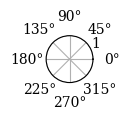

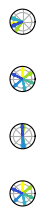

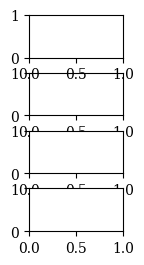

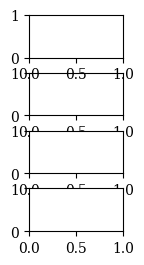

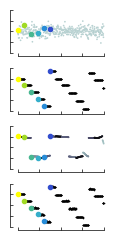

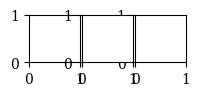

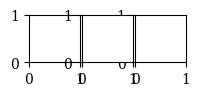

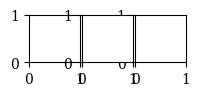

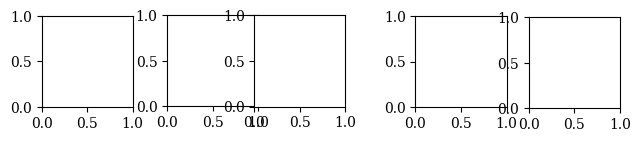

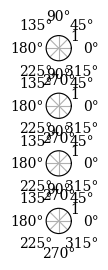

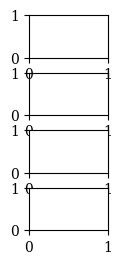

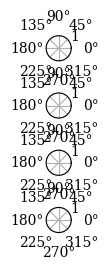

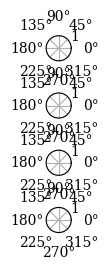

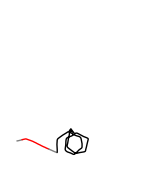

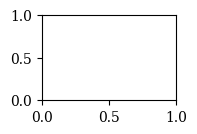

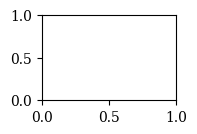

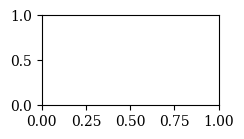

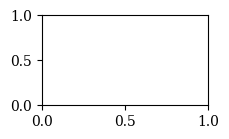

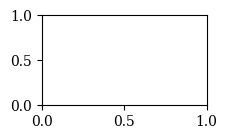

In [199]:
trajec = unifying_algorithm('laminar', t, goal_A, laminar_wind_dir, laminar_wind_mag, ground_speed, weight, ix_key, t0_ix=0)
#trajec = unifying_algorithm('steady', t, goal_A, steady_wind_dir, steady_wind_mag, ground_speed, weight, ix_key, t0_ix=200)
trajec = unifying_algorithm('unsteady', t, goal_A, unsteady_wind_dir, unsteady_wind_mag, ground_speed, weight, ix_key, t0_ix=200)
#trajec = unifying_algorithm('lowwind', t, goal_A, low_wind_dir, low_wind_mag, ground_speed, weight, ix_key)
trajec = unifying_algorithm('stillair', t, goal_A, still_air_wind_dir, still_air_wind_mag, ground_speed, weight, ix_key, t0_ix=0)

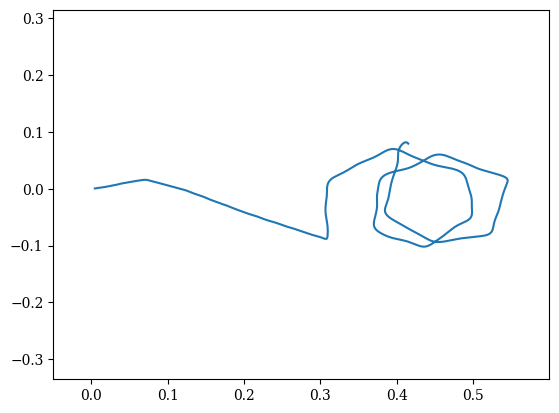

In [200]:
fig = plt.figure()
ax = fig.add_subplot(111)

x_pos = trajec[0]
y_pos = trajec[1]

ax.plot(x_pos, y_pos)

x_pos_middle = np.min(x_pos) + 0.5*(np.max(x_pos)-np.min(x_pos))
y_pos_middle = np.min(y_pos) + 0.5*(np.max(y_pos)-np.min(y_pos))
ax.set_xlim(x_pos_middle - 0.5*XY_PLOT_RANGE, x_pos_middle + 0.5*XY_PLOT_RANGE)
ax.set_ylim(y_pos_middle - 0.5*XY_PLOT_RANGE, y_pos_middle + 0.5*XY_PLOT_RANGE)

plt.show()

# Plot several trajectory examples

In [175]:
layout = fifi.svg_to_axes.FigureLayout(FIGURE_TEMPLATE, 
                                               autogenlayers=True, make_mplfigures=True, hide_layers=[])

windtypes = ['laminar','unsteady','stillair']

for windtype in windtypes:
    for i in range(3):
        goal_A, ground_speed, weight, ix_key = get_goal_A_ground_speed_weight(initial_goal_A=np.random.uniform(-180,180))

        t0_ix = np.random.randint(160,2000-401)
        laminar_wind_mag, laminar_wind_dir = get_wind_mag_dir(windtype, dt, t0_ix=t0_ix, N_points=len(t))

        
        trajec = unifying_algorithm(windtype, t, goal_A, laminar_wind_dir, laminar_wind_mag, ground_speed, weight, ix_key, make_plots=False)

        #laminar_wind_mag, laminar_wind_dir = get_wind_mag_dir(windtype, dt, t0_ix=t0_ix-60, N_points=60)
        #x_pre, y_pre = get_pre_surge_trajectory(laminar_wind_dir, laminar_wind_mag)

        
        
        x_pos = trajec[0]
        y_pos = trajec[1]
        
        ax = layout.axes[(windtype, 'ax'+str(i+1))]
        braid_analysis_plots.plot_arrowhead_trajectory(x_pos[0:10], y_pos[0:10], color='gray', linewidth=1, ax=ax, arrow_length=0)
        braid_analysis_plots.plot_arrowhead_trajectory(x_pos[10:70], y_pos[10:70], color='red', linewidth=1, ax=ax, arrow_length=0)
        braid_analysis_plots.plot_arrowhead_trajectory(x_pos[70:90], y_pos[70:90], color='gray', linewidth=1, ax=ax, arrow_length=0)
        braid_analysis_plots.plot_arrowhead_trajectory(x_pos[90:], y_pos[90:], color='black', linewidth=1, ax=ax, arrow_length=0.06)

        x_pos_middle = np.min(x_pos) + 0.5*(np.max(x_pos)-np.min(x_pos))
        y_pos_middle = np.min(y_pos) + 0.5*(np.max(y_pos)-np.min(y_pos))
        ax.set_xlim(x_pos_middle - 0.5*XY_PLOT_RANGE, x_pos_middle + 0.5*XY_PLOT_RANGE)
        ax.set_ylim(y_pos_middle - 0.5*XY_PLOT_RANGE, y_pos_middle + 0.5*XY_PLOT_RANGE)
        ax.set_aspect('equal')
        
        ax.set_aspect('equal')
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        fifi.mpl_functions.adjust_spines(ax, [], linewidth=0.5, 
                                         #spine_locations={'left': 2.5, 'bottom': 2.5,},
                                         tick_length=2.5)
        
    layout.append_figure_to_layer(layout.figures[windtype], windtype, cleartarget=True)
            ###########################################################################################
            
layout.write_svg(FIGURE_TEMPLATE)

mean lambda: 7.261815884242306
mean lambda: 7.112395832686104
mean lambda: 7.198728689700427
mean lambda: 3.745968593766735
mean lambda: 3.4848730066531823
mean lambda: 4.247573834491889
mean lambda: 0.0628275678262685
mean lambda: 0.07151735568550754
mean lambda: 0.06874814968133988


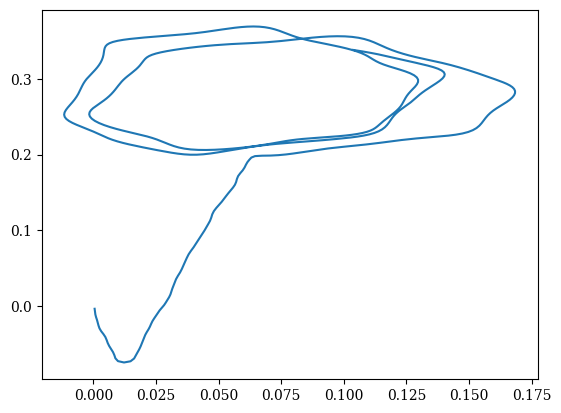

In [176]:
fig = plt.figure()
ax = fig.add_subplot(111)

ax.plot(x_pos, y_pos)

x_pos_middle = np.min(x_pos) + 0.5*(np.max(x_pos)-np.min(x_pos))
y_pos_middle = np.min(y_pos) + 0.5*(np.max(y_pos)-np.min(y_pos))
#ax.set_xlim(x_pos_middle - 0.5*XY_PLOT_RANGE, x_pos_middle + 0.5*XY_PLOT_RANGE)
#ax.set_ylim(y_pos_middle - 0.5*XY_PLOT_RANGE, y_pos_middle + 0.5*XY_PLOT_RANGE)

plt.show()

# make a bunch of trajectories

In [201]:
windtypes = ['laminar','unsteady','stillair']

df = pandas.DataFrame({})

n_trajecs = 200
obj_id = 0
for windtype in windtypes:
    for i in range(n_trajecs):
        goal_A, ground_speed, weight, ix_key = get_goal_A_ground_speed_weight(initial_goal_A=np.random.uniform(-180,180))

        t0_ix = np.random.randint(160,2000-401)
        laminar_wind_mag, laminar_wind_dir = get_wind_mag_dir(windtype, dt, t0_ix=t0_ix, N_points=len(t))
        
        trajec = unifying_algorithm(windtype, t, goal_A, laminar_wind_dir, laminar_wind_mag, ground_speed, weight, ix_key, make_plots=False)
        timestamp = np.arange(-10*0.01, (len(trajec[0])-10)*0.01, 0.01)

        
        
        df_trajec = pandas.DataFrame({'x_pos': trajec[0],
                     'y_pos': trajec[1],
                     'x_vel': trajec[2],
                     'y_vel': trajec[3],
                     'windtype': [windtype]*len(trajec[0]),
                     'obj_id': [obj_id]*len(trajec[0]),
                     'timestamp': timestamp})
        df = pandas.concat((df, df_trajec))

        obj_id += 1

mean lambda: 7.1736586768837505
mean lambda: 7.156977505385498
mean lambda: 7.23248806084609
mean lambda: 7.271057152638925
mean lambda: 7.1891876800299634
mean lambda: 7.151485863162675
mean lambda: 7.170574965484532
mean lambda: 7.238632641036934
mean lambda: 7.202909090874249
mean lambda: 7.279371455729979
mean lambda: 7.206667227481579
mean lambda: 7.232970758736315
mean lambda: 7.146728719258128
mean lambda: 7.211633449036549
mean lambda: 7.1772239757408105
mean lambda: 7.153267466471583
mean lambda: 7.174365532616435
mean lambda: 7.272946417085656
mean lambda: 7.220129576141571
mean lambda: 7.3069400821257044
mean lambda: 7.313183397850504
mean lambda: 7.306577605940236
mean lambda: 7.2272061943078665
mean lambda: 7.262587216766392
mean lambda: 7.179300904878668
mean lambda: 7.198505201029167
mean lambda: 7.194972630924339
mean lambda: 7.162733198374567
mean lambda: 7.201746359968243
mean lambda: 7.202909548765363
mean lambda: 7.111520972026349
mean lambda: 7.212349170816484
mean

In [202]:
df.to_hdf('model_trajectories.hdf', 'model_trajectories')

In [ ]:
pip install imp

In [ ]:
pynumdiff.total_variation_regularization.jerk?